DSCI 552 Homework 1
===================

- Name: Umaeshwer Shankar
- GitHub Username: umaeshwer
- USD ID: 7601-5514-88

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

## Loading the dataset

In [2]:
column_names = ['pelvic_incidence', 'pelvic_tilt', 'lumbar_lordosis_angle', 'sacral_slope', 'pelvic_radius', 'grade_of_spondylolisthesis', 'class']
df = pd.read_csv('../data/column_2C.dat', sep=' ', header=None)
df.columns = column_names

df['class'] = df['class'].map({'NO': 0, 'AB': 1})

In [3]:
df.head()

,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,grade_of_spondylolisthesis,class
0,63.03,22.55,39.61,40.48,98.67,-0.25,1
1,39.06,10.06,25.02,29.00,114.41,4.56,1
2,68.83,22.22,50.09,46.61,105.99,-3.53,1
3,69.30,24.65,44.31,44.64,101.87,11.21,1
4,49.71,9.65,28.32,40.06,108.17,7.92,1


In [4]:
df['class'].value_counts()

class
1    210
0    100
Name: count, dtype: int64

## Pre-processing and Exploratory Data Analysis

### Scatter plots

/var/folders/5c/3qs4gb0n2jjb1nf6m8w53dvh0000gn/T/ipykernel_57427/4054297636.py:5: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  pd.plotting.scatter_matrix(df, c=df['class'], marker='o', cmap='bwr', ax=fig.add_subplot(111))


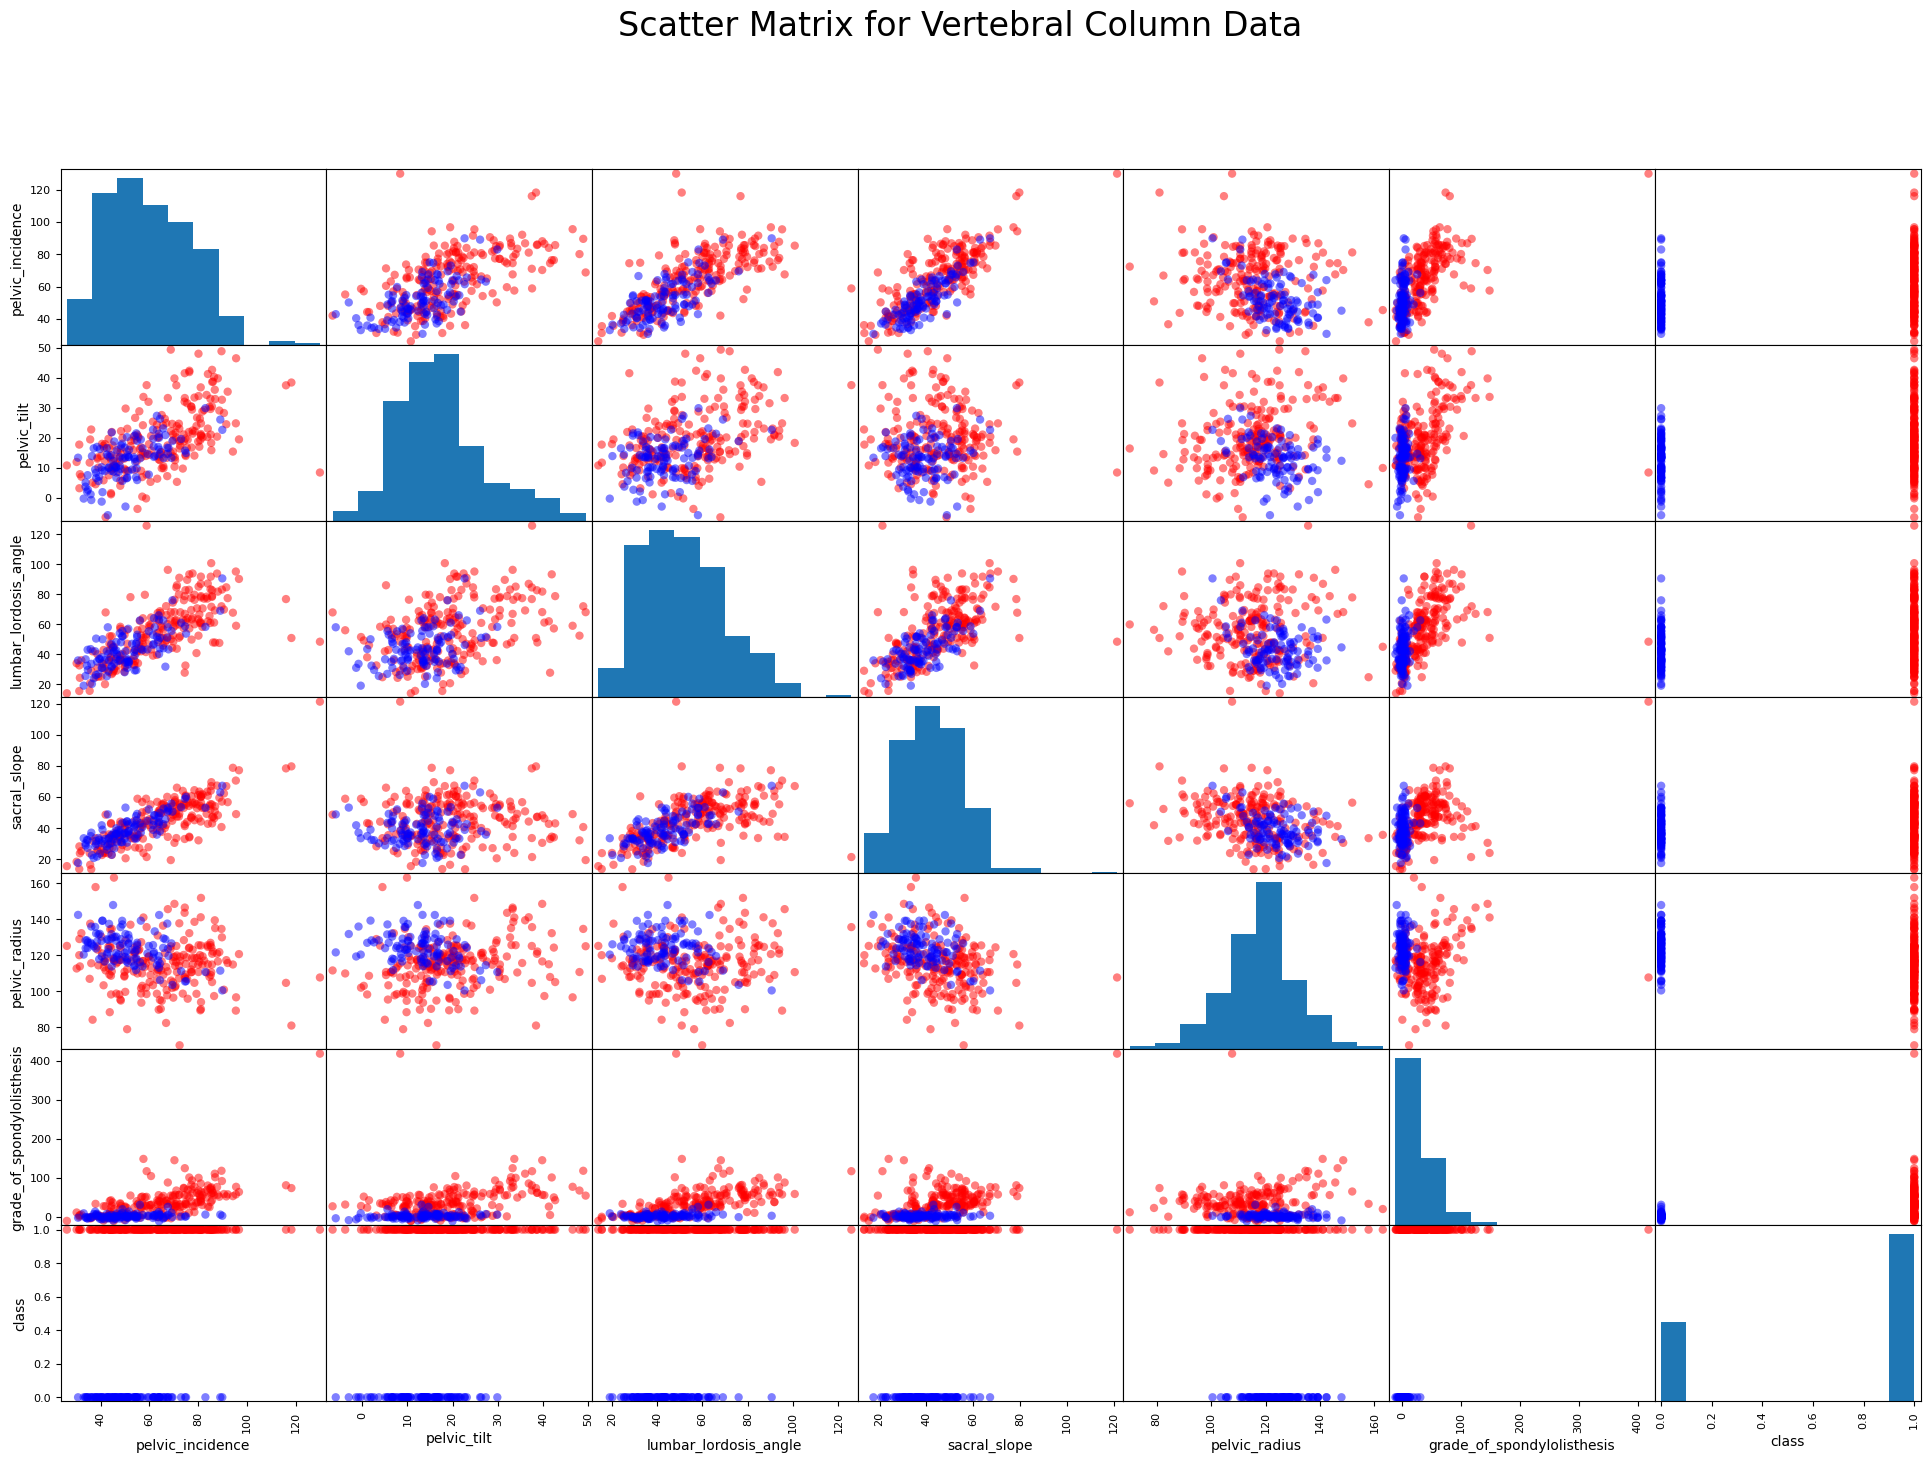

In [5]:
"""
Reference Link: https://pandas.pydata.org/docs/reference/api/pandas.plotting.scatter_matrix.html
"""
fig = plt.figure(figsize=(24, 16))
pd.plotting.scatter_matrix(df, c=df['class'], marker='o', cmap='bwr', ax=fig.add_subplot(111))
plt.suptitle('Scatter Matrix for Vertebral Column Data', fontsize=24)
plt.show()

### Box plots

/var/folders/5c/3qs4gb0n2jjb1nf6m8w53dvh0000gn/T/ipykernel_57427/1545940743.py:5: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df.plot.box(column=column_names[:-1], by='class', grid=False, patch_artist=True, ax=fig.add_subplot(111))


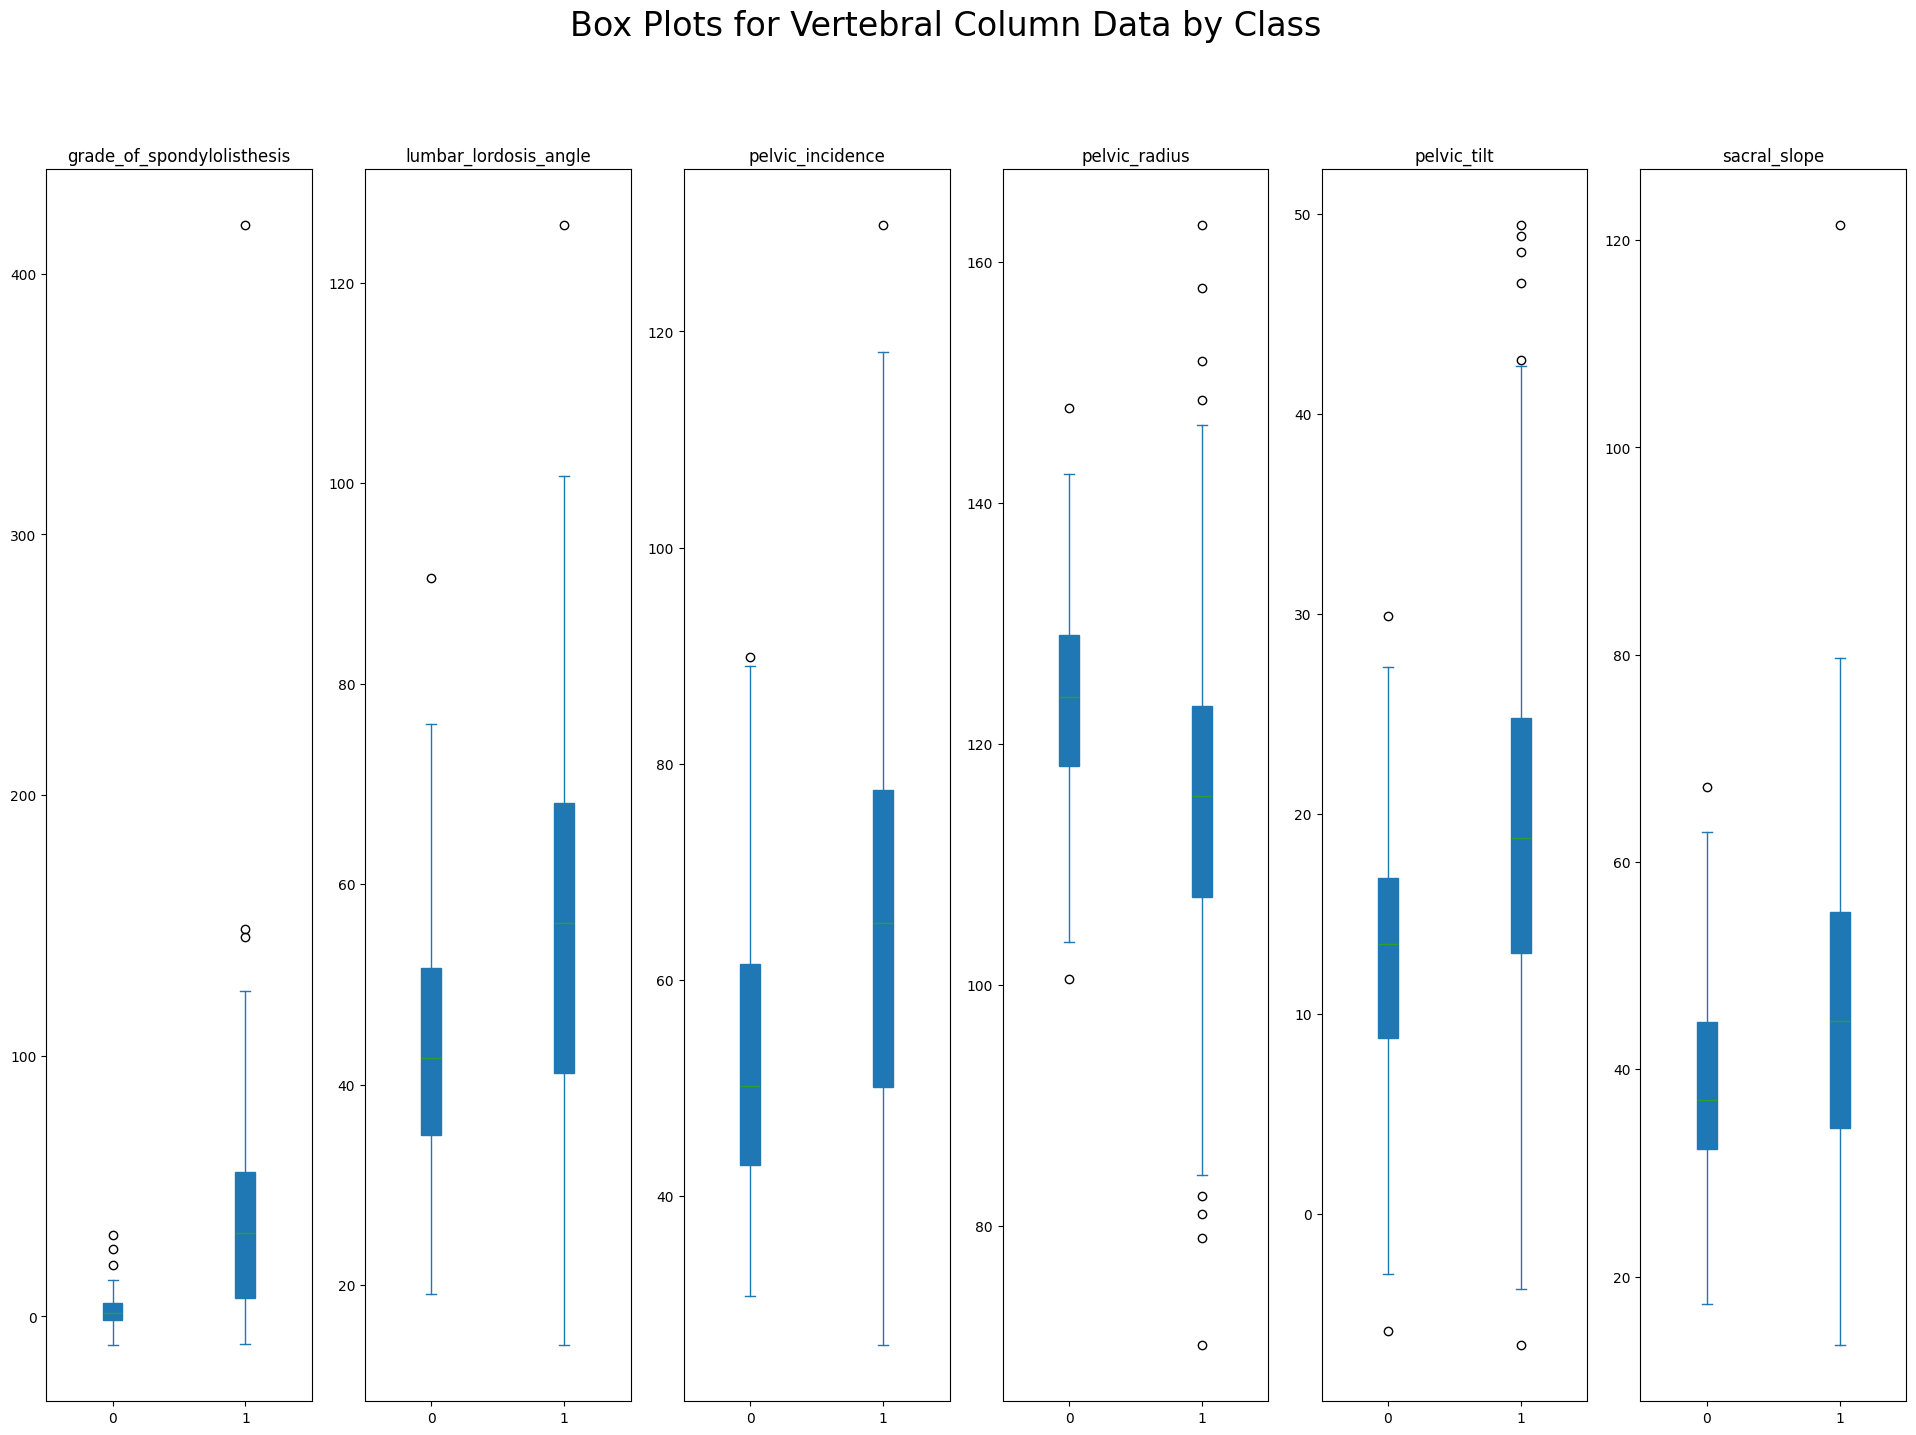

In [6]:
"""
Reference Link: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.box.html
"""
fig = plt.figure(figsize=(24, 16))
df.plot.box(column=column_names[:-1], by='class', grid=False, patch_artist=True, ax=fig.add_subplot(111))
plt.suptitle('Box Plots for Vertebral Column Data by Class', fontsize=24)
plt.show()

### Train-test split

In [7]:
train_zero = df[df['class'] == 0][:70]
train_one = df[df['class'] == 1][:140]
train = pd.concat([train_zero, train_one])

In [8]:
train.count()

pelvic_incidence              210
pelvic_tilt                   210
lumbar_lordosis_angle         210
sacral_slope                  210
pelvic_radius                 210
grade_of_spondylolisthesis    210
class                         210
dtype: int64

In [9]:
test_zero = df[df['class'] == 0][70:]
test_one = df[df['class'] == 1][140:]
test = pd.concat([test_zero, test_one])

In [10]:
test.count()

pelvic_incidence              100
pelvic_tilt                   100
lumbar_lordosis_angle         100
sacral_slope                  100
pelvic_radius                 100
grade_of_spondylolisthesis    100
class                         100
dtype: int64

## Classification using KNN on the Vertebral Column dataset

In [11]:
def knn_classifier(train, test, k_list, metric='euclidean', weights=None, p=None):
    scores, train_scores = {}, {}
    for k in k_list:
        knn = sklearn.neighbors.KNeighborsClassifier(n_neighbors=int(k), metric=metric, weights=weights, p=p)
        knn.fit(train.iloc[:, :-1], train['class'])
        score = knn.score(test.iloc[:, :-1], test['class'])
        train_scores[int(k)] = 1-knn.score(train.iloc[:, :-1], train['class'])
        scores[int(k)] = 1-score
    best_k = min(scores, key=scores.get)
    print(f'Best k: {best_k} with error rate: {scores[best_k]}')
    return best_k, scores, train_scores

### Finding optimal K (Number of neighbors)

In [12]:
k_list = np.linspace(208, 1, 70)
best_k, scores, train_scores = knn_classifier(train, test, k_list, metric='euclidean')


Best k: 4 with error rate: 0.06000000000000005


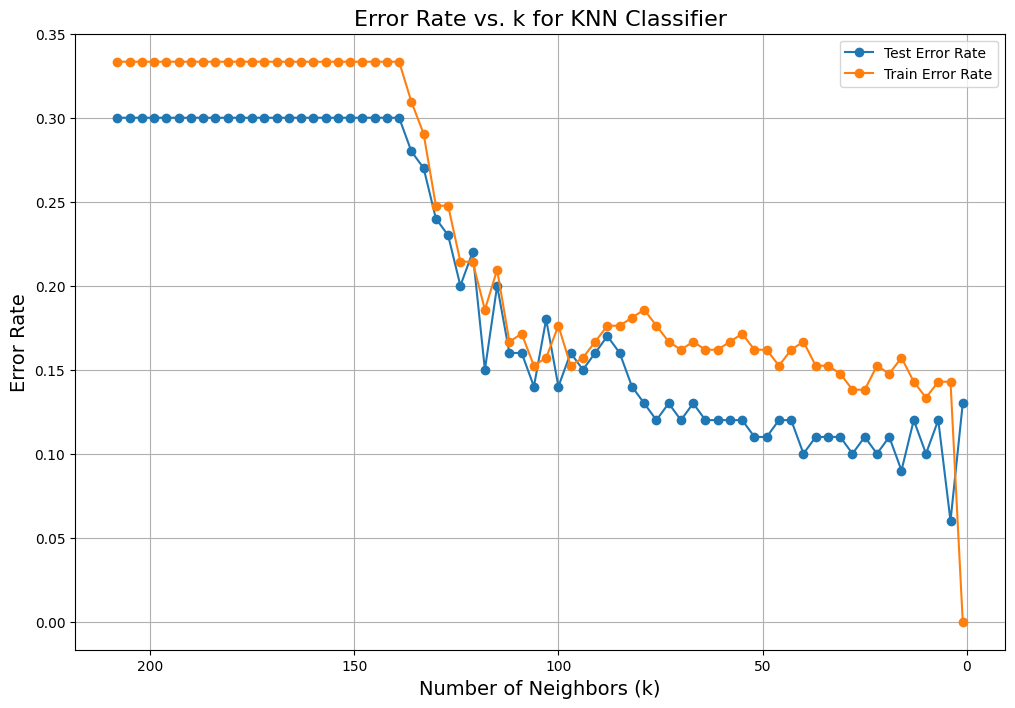

In [13]:
fig = plt.figure(figsize=(12, 8))
plt.plot(k_list, list(scores.values()), marker='o', label='Test Error Rate')
plt.plot(k_list, list(train_scores.values()), marker='o', label='Train Error Rate')
plt.grid()
plt.title('Error Rate vs. k for KNN Classifier', fontsize=16)
plt.xlabel('Number of Neighbors (k)', fontsize=14)
plt.ylabel('Error Rate', fontsize=14)
plt.gca().invert_xaxis()
plt.legend()
plt.show()

In [14]:
"""
Reference Links:

1. https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html
2. https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score
3. https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html
4. https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score

"""
print(f"k: {best_k}")

knn = sklearn.neighbors.KNeighborsClassifier(n_neighbors=best_k, metric='euclidean') # choosing Euclidean distance
knn.fit(train.iloc[:, :-1], train['class'])

confusion_matrix = sklearn.metrics.confusion_matrix(test['class'], knn.predict(test.iloc[:, :-1]))
print(f"Confusion matrix: {confusion_matrix}")

true_positive_rate = sklearn.metrics.recall_score(test['class'], knn.predict(test.iloc[:, :-1]))
print(f"True Positive Rate/Recall: {true_positive_rate}")

true_negative_rate = sklearn.metrics.recall_score(test['class'], knn.predict(test.iloc[:, :-1]), pos_label=0)
print(f"True Negative Rate: {true_negative_rate}")

precision = sklearn.metrics.precision_score(test['class'], knn.predict(test.iloc[:, :-1]))
print(f"Precision: {precision}")

f1_score = sklearn.metrics.f1_score(test['class'], knn.predict(test.iloc[:, :-1]))
print(f"F1 Score: {f1_score}")


k: 4
Confusion matrix: [[25  5]
 [ 1 69]]
True Positive Rate/Recall: 0.9857142857142858
True Negative Rate: 0.8333333333333334
Precision: 0.9324324324324325
F1 Score: 0.9583333333333334


### Training set size v/s Test error rate

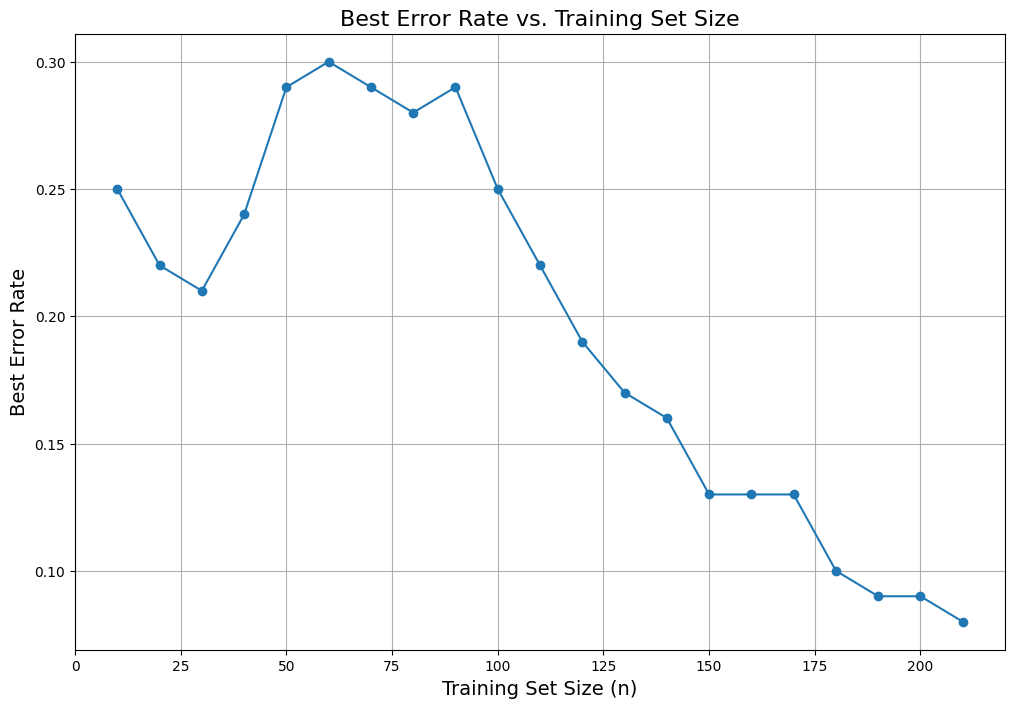

In [15]:
n_list = np.linspace(10, 210, 21)
best_error_rates = []

for n in n_list:
    train_zero = df[df['class'] == 0][:int(n//3)]
    train_one = df[df['class'] == 1][:int(n) - int(n//3)]
    train = pd.concat([train_zero, train_one])
    # print(len(train))

    scores = {}
    k_list = np.linspace(1, int(n), (int(n)-1)//5)
    # print(k_list)

    for k in k_list:
        knn = sklearn.neighbors.KNeighborsClassifier(n_neighbors=int(k), metric='euclidean') # choosing Euclidean distance
        knn.fit(train.iloc[:, :-1], train['class'])
        score = knn.score(test.iloc[:, :-1], test['class'])
        error_rate = 1 - score
        scores[int(k)] = error_rate
    best_k = min(scores, key=scores.get)
    best_error_rates.append(scores[best_k])

fig = plt.figure(figsize=(12, 8))
plt.plot(n_list, best_error_rates, marker='o')
plt.grid()
plt.title('Best Error Rate vs. Training Set Size', fontsize=16)
plt.xlabel('Training Set Size (n)', fontsize=14)
plt.ylabel('Best Error Rate', fontsize=14)
plt.show()

## Replacing Euclidean metric with Minkowski/Mahalanobis distance

### Minkowski distance (p = 1) = Manhattan distance

In [23]:
k_list = np.linspace(196, 1, 40)
best_k, _, _ = knn_classifier(train, test, k_list, metric='minkowski', p=1) # choosing Minkowski distance

Best k: 26 with error rate: 0.10999999999999999


### Minkowski distance (Exponential)

In [28]:
p_list = np.logspace(0.1, 1, 10)
scores = {}
for p in p_list:
    knn = sklearn.neighbors.KNeighborsClassifier(n_neighbors=best_k, p=p) # choosing k = 26
    knn.fit(train.iloc[:, :-1], train['class'])
    score = knn.score(test.iloc[:, :-1], test['class'])
    scores[p] = 1-score
best_p = min(scores, key=scores.get)
print(f"Best log(p): {np.log10(best_p)} with error rate: {scores[best_p]}")

Best log(p): 0.10000000000000002 with error rate: 0.09999999999999998


### Minkowski distance (p -> inf) = Chebyshev distance

In [29]:
scores = {}
best_k = knn_classifier(train, test, k_list, metric='minkowski', p=np.inf) # choosing Minkowski distance with power = inf for Chebyshev distance

Best k: 16 with error rate: 0.07999999999999996


### Mahalanobis distance

In [30]:
scores = {}
for k in k_list:
    V = np.cov(train.iloc[:, :-1].T)
    VI = np.linalg.pinv(V)
    knn = sklearn.neighbors.KNeighborsClassifier(n_neighbors=int(k), metric='mahalanobis', metric_params={'VI': VI}) # choosing mahalanobis distance
    knn.fit(train.iloc[:, :-1], train['class'])
    score = knn.score(test.iloc[:, :-1], test['class'])
    scores[int(k)] = 1-score
best_k = min(scores, key=scores.get)
print(f'Best k: {best_k} with error rate: {scores[best_k]}')

Best k: 6 with error rate: 0.17000000000000004


## Weighted polling decisions

### Euclidean

In [31]:
k_list = np.linspace(196, 1, 40)
best_k = knn_classifier(train, test, k_list, metric='euclidean', weights='distance') # choosing Euclidean distance with distance-based weighting

Best k: 6 with error rate: 0.09999999999999998


### Manhattan

In [21]:
best_k = knn_classifier(train, test, k_list, metric='minkowski', p=1, weights='distance') # choosing Manhattan distance with distance-based weighting


Best k: 26 with error rate: 0.09999999999999998


### Chebyshev

In [22]:
best_k = knn_classifier(train, test, k_list, metric='minkowski', p=np.inf, weights='distance') # choosing Chebyshev distance with distance-based weighting


Best k: 61 with error rate: 0.10999999999999999


## Lowest Training Error Rate

Lowest training error rate achieved is zero when k = 1. In this case, we only consider the nearest point to each data point, which is itself.